In [ ]:
%pip install --upgrade pip
%pip install tensorflow scikit-learn matplotlib opencv-python Pillow numpy

## Introduction

This document has been divided by headers representing assignments B1-B6 of Task 2 respectively. For example, under the header B1. DATA CLEANING PROCESS, you will find the code for "handling noise, blurriness, occlusions, and removing null or erroneous images or unusual characters in images" (WGU, 2026). Additionally, code for image resolution can be found under B2. IMAGE RESOLUTION, while code for data splitting can be found under B6. DATA SPLITTING. This was done to ensure that everything is organized and easier to locate.

In [25]:
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import numpy as np
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import cv2
from PIL import Image


Before any work is done on the data, we must first load the CIFAR-10 dataset and confirming the shape of our test and train datasets.

In [26]:
CIFAR10 = cifar10.load_data()
(X_train, y_train), (X_test, y_test) = CIFAR10
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


## B1. DATA CLEANING PROCESS

For the first step in our data cleaning process, we concatenate the images and labels to provide arrays representing the total images and labels for the entire dataset. We then zip these datasets together and create an index that reports back the specific image or label that is presenting issues.  We use numpy to check for both NaN values and zero value images in the image set, as well as for NaN values and labels that fall outside of the 10 expected indices (0-9). We follow this with a verification for compatibility of all images using Pillow. Tools used for data cleaning include NumPy, OpenCV, Pillow, Matplotlib, Keras, and scikit-learn.

In [ ]:
CIFAR_images = np.concatenate((X_train, X_test), axis=0)
CIFAR_labels = np.concatenate((y_train, y_test), axis=0)

corrupt_index = []

for idx, (img_array, label) in enumerate(zip(CIFAR_images, CIFAR_labels)):
    if np.isnan(img_array).any() or np.all(img_array == 0) or np.isnan(label).any() or not (0 <= label.item() < 10):
        corrupt_index.append(idx)
        continue
    try:
        img = Image.fromarray(img_array)
    except Exception as e:
        corrupt_index.append(idx)

if corrupt_index:
    print(f"Found {len(corrupt_index)} corrupt images at indices: {corrupt_index}")
else:
    print("No corrupt images found.")

No corrupt images found.


Next, we check for any issues with the images themselves, including noise, blurriness, and occlusions. We do this by converting the images to grayscale and running a for loop checking for high standard deviation (noise), low standard deviation (occlusion), and low laplacian variance (blurriness). Any issues are entered into their respective indices, defined above the for loop. The loop ends with a printout of the amount of issues detected and their respective index in the combined dataset. 

In [28]:
noise_index = []
blur_index = []
occlusion_index = []

for idx, (img_array) in enumerate(CIFAR_images):
    gs = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) 
    if gs.std() > 100: 
        noise_index.append(idx)
    
    laplacian_var = cv2.Laplacian(gs, cv2.CV_64F).var() 
    if laplacian_var < 10:
        blur_index.append(idx)

    if gs.std() < 5: 
        occlusion_index.append(idx)

if noise_index: 
    print(f"Found {len(noise_index)} noisy images at indices: {noise_index}") #This prints the number of noisy images found and their corresponding indices in the dataset.
if blur_index:
        print(f"Found {len(blur_index)} blurry images at indices: {blur_index}") #This prints the number of blurry images found and their corresponding indices in the dataset.
if occlusion_index:
    print(f"Found {len(occlusion_index)} occluded images at indices: {occlusion_index}") #This prints the number of occluded images found and their corresponding indices in the dataset.

Found 41 noisy images at indices: [3837, 4273, 4331, 4564, 5311, 7260, 7441, 7635, 8098, 10589, 13497, 14237, 16419, 17717, 19316, 21399, 25109, 26984, 27590, 28238, 29586, 31728, 32252, 32791, 33007, 37156, 39092, 39175, 41744, 45615, 45976, 49964, 51494, 53471, 53688, 54753, 55263, 56942, 58537, 58684, 59482]
Found 1 occluded images at indices: [36169]


We check all the flagged images to confirm there is an issue. Below is an example of pulling the occluded image.

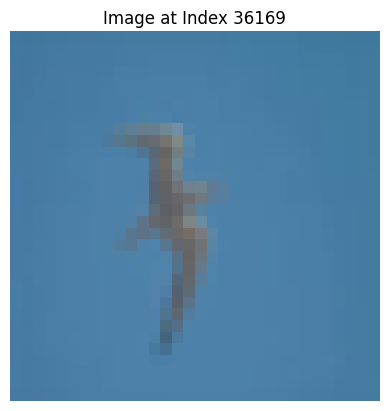

In [ ]:
if occlusion_index:
    plt.imshow(CIFAR_images[occlusion_index[0]])
    plt.title(f"Image at Index {occlusion_index[0]}")
    plt.axis('off')
    plt.show()
else:
    print("No occluded images to display.")

To review the noisy images, we would just swap out the index name and indices.

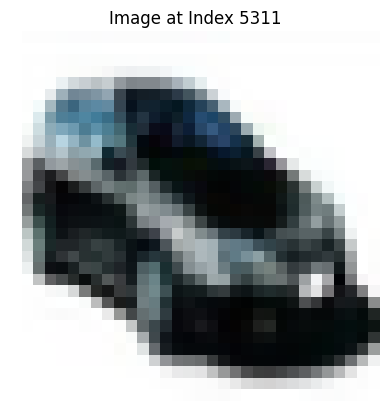

In [ ]:
if len(noise_index) >= 5:
    plt.imshow(CIFAR_images[noise_index[4]])
    plt.title(f"Image at Index {noise_index[4]}")
    plt.axis('off')
    plt.show()
elif noise_index:
    plt.imshow(CIFAR_images[noise_index[0]])
    plt.title(f"Image at Index {noise_index[0]}")
    plt.axis('off')
    plt.show()
else:
    print("No noisy images to display.")

After reviewing the flagged images, I determined that there are not any quality issues. Rather it is the image size (32x32) that is causing the flags. Because of this, I will not remove or modify the images.

## B2. IMAGE RESOLUTION

CIFAR-10 is natively divided into training and test sets and the images are randomized (Counts, 2023), so we will format the images using X_train, y_train, X_test, and y_test. As we will be using a standard CNN, we will preserve the dimensions (32x32x3). A fourth dimension (batch size) will be added during training. 

For our X sets, we convert pixel values to float32 and divide by 255, thereby normalizing the pixel values of the images (scaling values from range 0-255 to range 0-1, improving training efficiency).

Additionally, we convert our 10 class labels into one-hot encoding vectors to enable the use of softmax in our final layer (see B5).

In [31]:
X_train = X_train.astype('float32') / 255.0 #We convert the pixel values of the training images to float32 data type and normalize them by dividing by 255.0. 
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

## B3. PREPROCESSING GOALS AND CODE

The goals of preprocessing are to ensure that: 1. All images in the dataset are properly formatted and sized for input into a CNN, 2. All images in both the image and label sets are free from any corruption or initial abnormalities, 3. All labels are one-hot encoded for a multiclass output with a softmax function, and 4. The resulting clean dataset is saved for use in our model.
Data augmentation will not be applied in preprocessing, and instead applied as data augmentation layers in the model itself.

The packages used for confirming the quality of the data are Numpy, OpenCV (cv2), Pillow, Keras, and scikit-learn. The packages used to test for corruption or abnormalities in the data are Numpy and Pillow. The package used for one-hot encoding is Keras. Finally, Numpy is used for saving the clean dataset.

## B4. PADDING

As images in the CIFAR-10 dataset are all 32x32, we will not be adding any padding to the images or resizing them during preprocessing. This would be used if the images were different sizes or if we were using a model which requires larger inputs. Padding will be used for the CNN layers, and since we will be using the Keras/Tensorflow SDK, we will apply this by including "padding = 'same'", meaning the output size will match the input size.

## B5. CATEGORIES AND ACTIVATION FUNCTION

The CIFAR-10 has 10 labels, which have been one-hot encoded under B2, above. Since this is a multiclass classification, we will use a softmax activation function for the final dense layer.

## B6. DATA SPLITTING

While the initial train-test-split was not necessary for CIFAR-10, we do still need to use the function to create our validation set, which is important for fine-tuning our parameters. This validation set will be used during development to tune hyperparameters and evaluate performance without exposing the model to the training set. We include shuffling in the split to ensure that the validation set is representative.

In [32]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, shuffle=True, test_size=0.2, random_state=42)

We then print the size of all of our sets to confirm the split.

In [33]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (40000, 32, 32, 3)
y_train shape: (40000, 10)
X_val shape: (10000, 32, 32, 3)
y_val shape: (10000, 10)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


Finally, we save our processed data for use in Task 3. In order to meet submission requirements, the processed data is saved as unsigned 8-bit image arrays. These will be converted back to float32 arrays when loaded for modeling.

In [35]:
np.savez_compressed(
    'cifar10_clean.npz',
    X_train=(X_train * 255).astype(np.uint8),
    y_train=y_train.astype(np.uint8),
    X_val=(X_val * 255).astype(np.uint8),
    y_val=y_val.astype(np.uint8),
    X_test=(X_test * 255).astype(np.uint8),
    y_test=y_test.astype(np.uint8)
)

## REFERENCES

WGU. (2026). STN1 - STN1 Task 2: Data Cleaning. Retrieved from WGU: https://tasks.wgu.edu/student/012686750/course/36680018/task/5140/overview

Counts, Mason. (2023, July 31). Classifying the CIFAR-10 Dataset with Transfer Learning (and Tensorflow Keras). Retrieved from Medium: https://medium.com/@masonthecount/classifying-the-cifar-10-dataset-with-transfer-learning-and-tensorflow-keras-237f4cbe5fd9